In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi gaya visualisasi agar seragam dan profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries berhasil dimuat. Siap melakukan EDA mendalam.")

Libraries berhasil dimuat. Siap melakukan EDA mendalam.


In [47]:
print("=== 1. DATA INTEGRITY CHECK: POWER HISTORY ===")
df_power = pd.read_csv('../data/power_history.csv')

# 1. Cek ukuran data
print(f"Dimensi Dataset: {df_power.shape[0]} baris, {df_power.shape[1]} kolom")

# 2. Cek tipe data dan kelengkapan informasi
print("\nInformasi Struktur Data:")
print(df_power.info())

# 3. Validasi Missing Values (Wajib untuk membuktikan data bersih)
missing_power = df_power.isnull().sum()
print("\nJumlah Missing Value per Kolom:")
print(missing_power)

# 4. Cek data duplikat
duplicate_power = df_power.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {duplicate_power}")

print("\nKESIMPULAN VALIDASI: Data bersih, tidak ada missing value atau duplikasi. Siap digunakan!")
df_power.head()

=== 1. DATA INTEGRITY CHECK: POWER HISTORY ===
Dimensi Dataset: 24000 baris, 8 kolom

Informasi Struktur Data:
<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            24000 non-null  str    
 1   timestamp     24000 non-null  str    
 2   hour          24000 non-null  int64  
 3   day_of_week   24000 non-null  int64  
 4   temperature   24000 non-null  float64
 5   prev_demand   24000 non-null  float64
 6   zone          24000 non-null  str    
 7   power_demand  24000 non-null  float64
dtypes: float64(3), int64(2), str(3)
memory usage: 2.5 MB
None

Jumlah Missing Value per Kolom:
id              0
timestamp       0
hour            0
day_of_week     0
temperature     0
prev_demand     0
zone            0
power_demand    0
dtype: int64

Jumlah Baris Duplikat: 0

KESIMPULAN VALIDASI: Data bersih, tidak ada missing value atau duplikasi. Siap dig

,id,timestamp,hour,day_of_week,temperature,prev_demand,zone,power_demand
0,PWR-20250901-1000001,2025-09-01T00:00:00Z,0,0,27.0,158.40,zone1,136.83
1,PWR-20250901-2000001,2025-09-01T00:00:00Z,0,0,27.0,68.58,zone2,96.67
2,PWR-20250901-3000001,2025-09-01T00:00:00Z,0,0,27.0,88.41,zone3,74.76
3,PWR-20250901-4000001,2025-09-01T00:00:00Z,0,0,27.0,1147.02,zone4,1223.72
4,PWR-20250901-1000002,2025-09-01T01:00:00Z,1,0,21.8,185.54,zone1,169.84


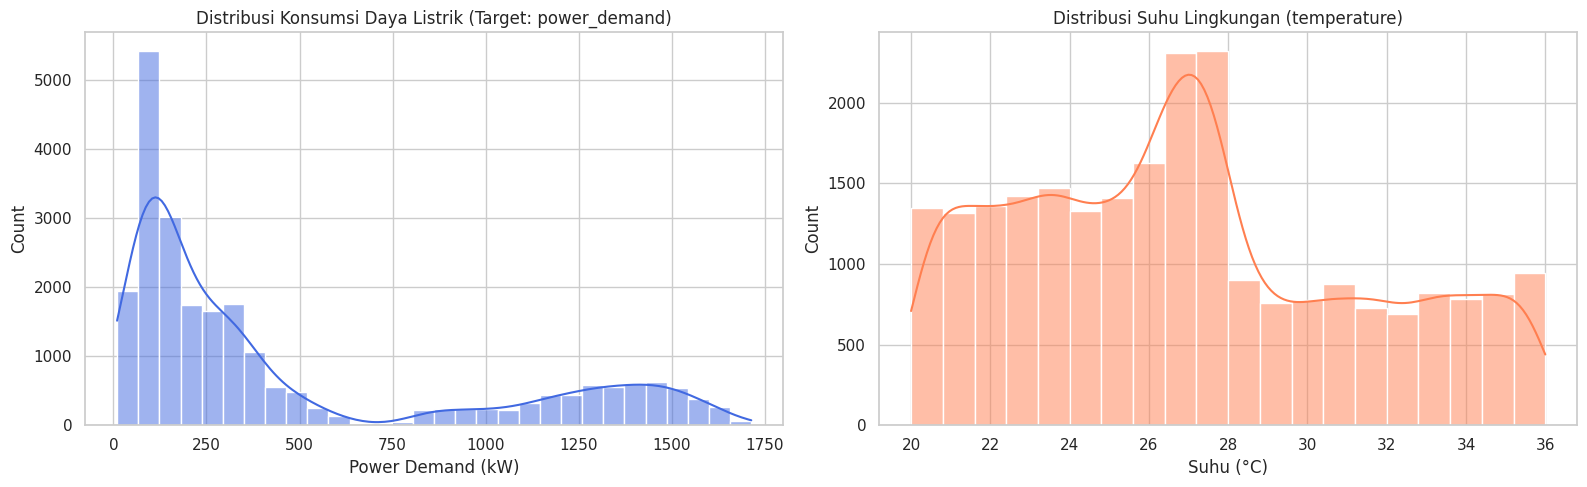

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi Target (Power Demand)
sns.histplot(df_power['power_demand'], kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title('Distribusi Konsumsi Daya Listrik (Target: power_demand)')
axes[0].set_xlabel('Power Demand (kW)')

# Distribusi Suhu
sns.histplot(df_power['temperature'], kde=True, ax=axes[1], color='coral', bins=20)
axes[1].set_title('Distribusi Suhu Lingkungan (temperature)')
axes[1].set_xlabel('Suhu (°C)')

plt.tight_layout()
plt.show()

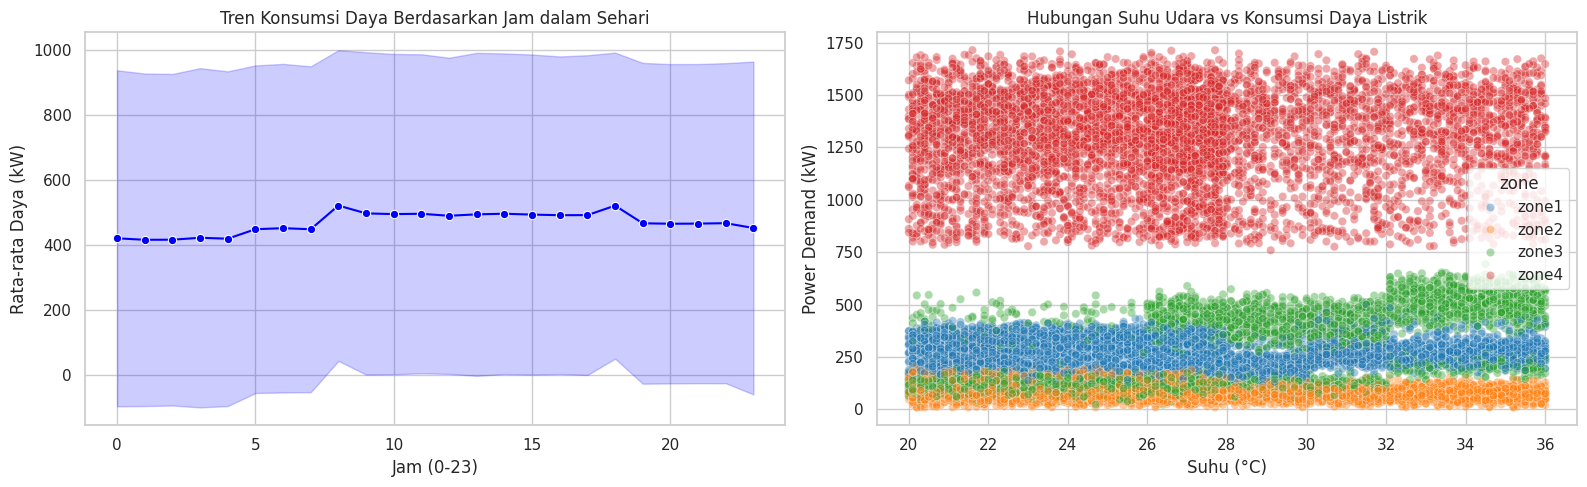

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hubungan Jam vs Power Demand (Membuktikan pola Peak Hours)
sns.lineplot(data=df_power, x='hour', y='power_demand', ax=axes[0], color='blue', marker='o', errorbar='sd')
axes[0].set_title('Tren Konsumsi Daya Berdasarkan Jam dalam Sehari')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Rata-rata Daya (kW)')

# Hubungan Suhu vs Power Demand (Membuktikan dampak cuaca terhadap beban listrik)
sns.scatterplot(data=df_power, x='temperature', y='power_demand', hue='zone', alpha=0.4, ax=axes[1], palette='tab10')
axes[1].set_title('Hubungan Suhu Udara vs Konsumsi Daya Listrik')
axes[1].set_xlabel('Suhu (°C)')
axes[1].set_ylabel('Power Demand (kW)')

plt.tight_layout()
plt.show()

=== ANALISIS MENDALAM: PENGARUH ZONA PADA KONSUMSI DAYA ===


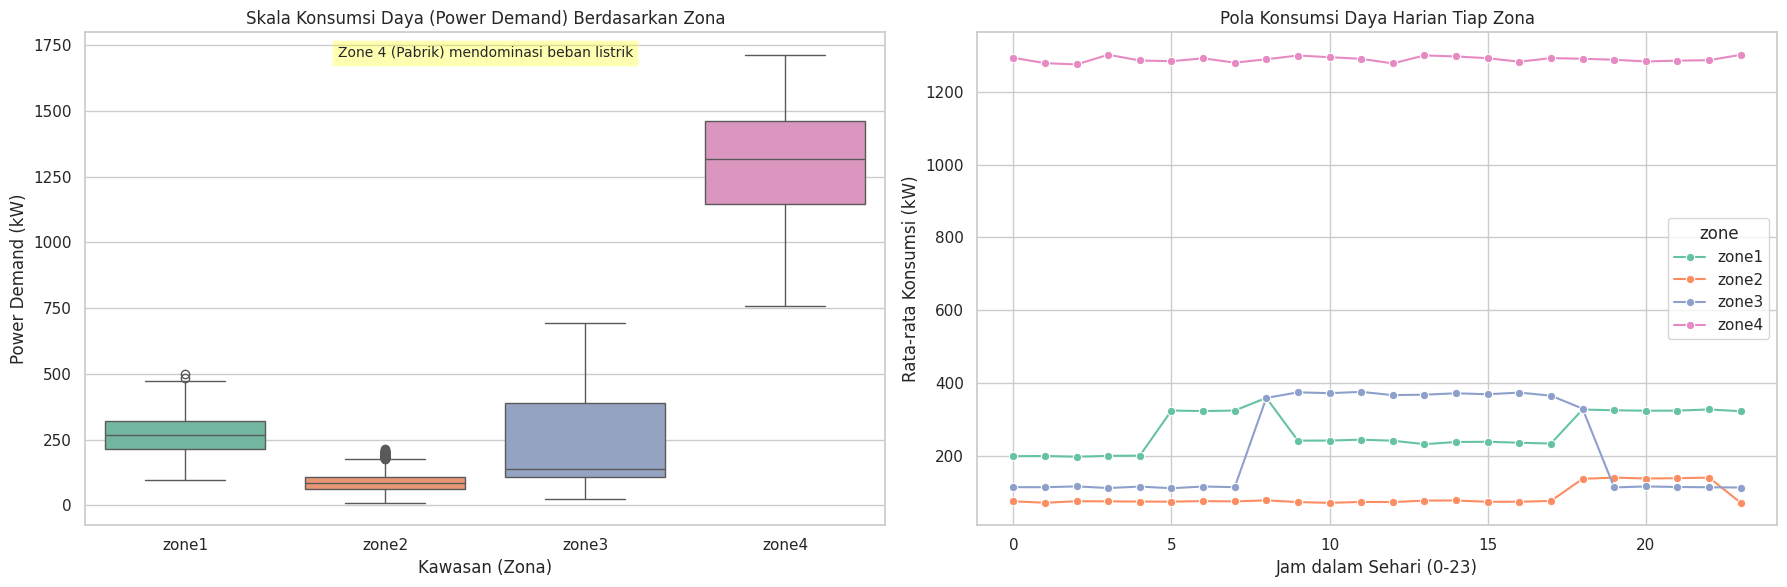

Interpretasi:
- Zone 4 (Pabrik): Beban raksasa dan konstan.
- Zone 3 (Komersial): Beban memuncak di jam kerja (08:00 - 18:00).
- Zone 1 & 2 (Residensial): Memiliki ciri khas lonjakan beban di malam hari.


In [50]:
print("=== ANALISIS MENDALAM: PENGARUH ZONA PADA KONSUMSI DAYA ===")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Boxplot skala konsumsi per zona
sns.boxplot(data=df_power, x='zone', y='power_demand', hue='zone', palette='Set2', ax=axes[0])
axes[0].set_title('Skala Konsumsi Daya (Power Demand) Berdasarkan Zona')
axes[0].set_xlabel('Kawasan (Zona)')
axes[0].set_ylabel('Power Demand (kW)')
axes[0].text(0.5, 0.95, 'Zone 4 (Pabrik) mendominasi beban listrik', 
             horizontalalignment='center', transform=axes[0].transAxes, 
             fontsize=10, bbox=dict(facecolor='yellow', alpha=0.3))

# Grafik 2: Tren beban harian per zona (Lineplot)
sns.lineplot(data=df_power, x='hour', y='power_demand', hue='zone', marker='o', errorbar=None, palette='Set2', ax=axes[1])
axes[1].set_title('Pola Konsumsi Daya Harian Tiap Zona')
axes[1].set_xlabel('Jam dalam Sehari (0-23)')
axes[1].set_ylabel('Rata-rata Konsumsi (kW)')

plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Zone 4 (Pabrik): Beban raksasa dan konstan.")
print("- Zone 3 (Komersial): Beban memuncak di jam kerja (08:00 - 18:00).")
print("- Zone 1 & 2 (Residensial): Memiliki ciri khas lonjakan beban di malam hari.")

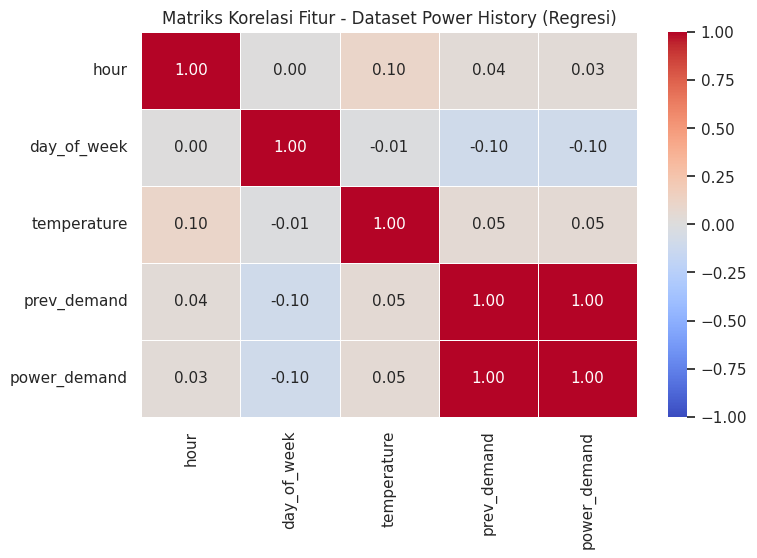

In [51]:
plt.figure(figsize=(8, 5))
# Memilih hanya kolom numerik untuk korelasi
numerical_cols_p = df_power.select_dtypes(include=[np.number]).columns
corr_matrix_p = df_power[numerical_cols_p].corr()

sns.heatmap(corr_matrix_p, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur - Dataset Power History (Regresi)')
plt.show()

In [52]:
print("=== 2. DATA INTEGRITY CHECK: GRID QUALITY ===")
df_grid = pd.read_csv('../data/grid_quality.csv')

print(f"Dimensi Dataset: {df_grid.shape[0]} baris, {df_grid.shape[1]} kolom")

# Cek Missing Value & Duplikasi
print(f"Total Missing Values: {df_grid.isnull().sum().sum()}")
print(f"Total Baris Duplikat: {df_grid.duplicated().sum()}")

# Cek Keseimbangan Kelas (Class Balance) untuk Klasifikasi
print("\nDistribusi Kelas Target (grid_status):")
print(df_grid['grid_status'].value_counts())

print("\nKESIMPULAN VALIDASI: Data siap digunakan untuk training model klasifikasi multi-kelas.")

=== 2. DATA INTEGRITY CHECK: GRID QUALITY ===
Dimensi Dataset: 24000 baris, 9 kolom
Total Missing Values: 0
Total Baris Duplikat: 0

Distribusi Kelas Target (grid_status):
grid_status
Normal      17970
Warning      3424
Critical     2606
Name: count, dtype: int64

KESIMPULAN VALIDASI: Data siap digunakan untuk training model klasifikasi multi-kelas.


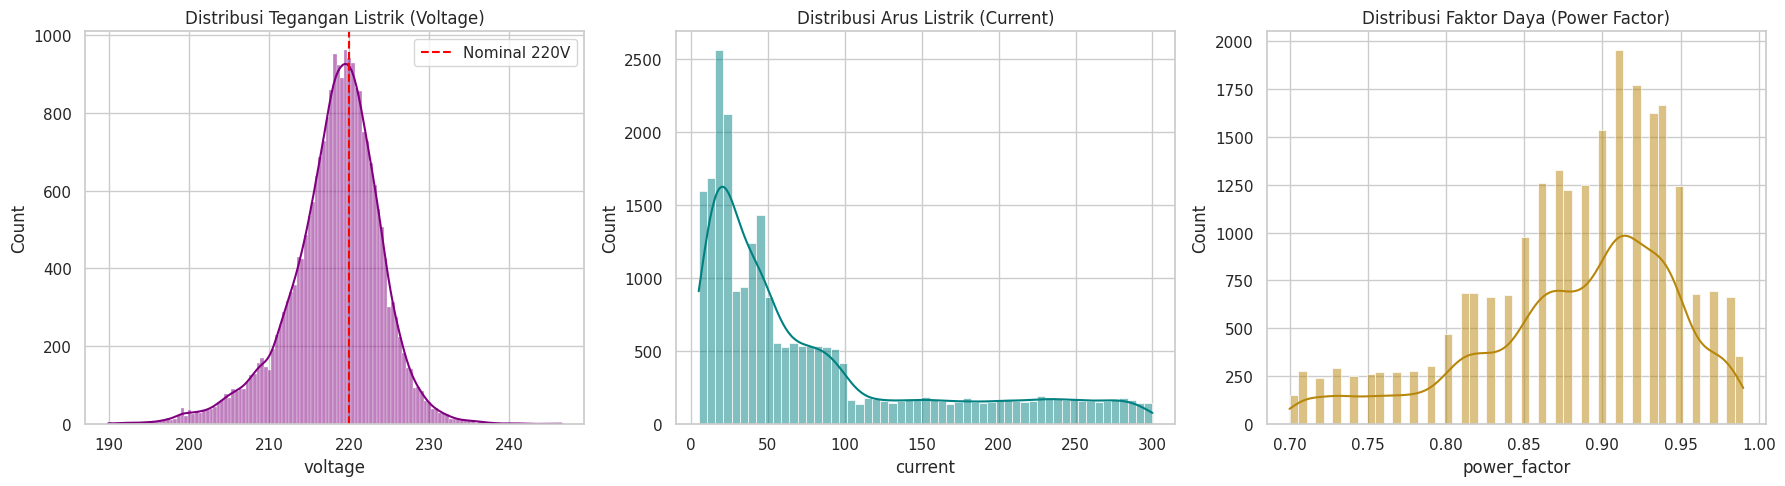

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi Tegangan (Voltage)
sns.histplot(df_grid['voltage'], kde=True, ax=axes[0], color='purple')
axes[0].axvline(220, color='red', linestyle='--', label='Nominal 220V')
axes[0].set_title('Distribusi Tegangan Listrik (Voltage)')
axes[0].legend()

# Distribusi Arus (Current)
sns.histplot(df_grid['current'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribusi Arus Listrik (Current)')

# Distribusi Power Factor
sns.histplot(df_grid['power_factor'], kde=True, ax=axes[2], color='darkgoldenrod')
axes[2].set_title('Distribusi Faktor Daya (Power Factor)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_171870/1443603887.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grid, x='grid_status', y='power_factor', palette='Set2', ax=axes[1])


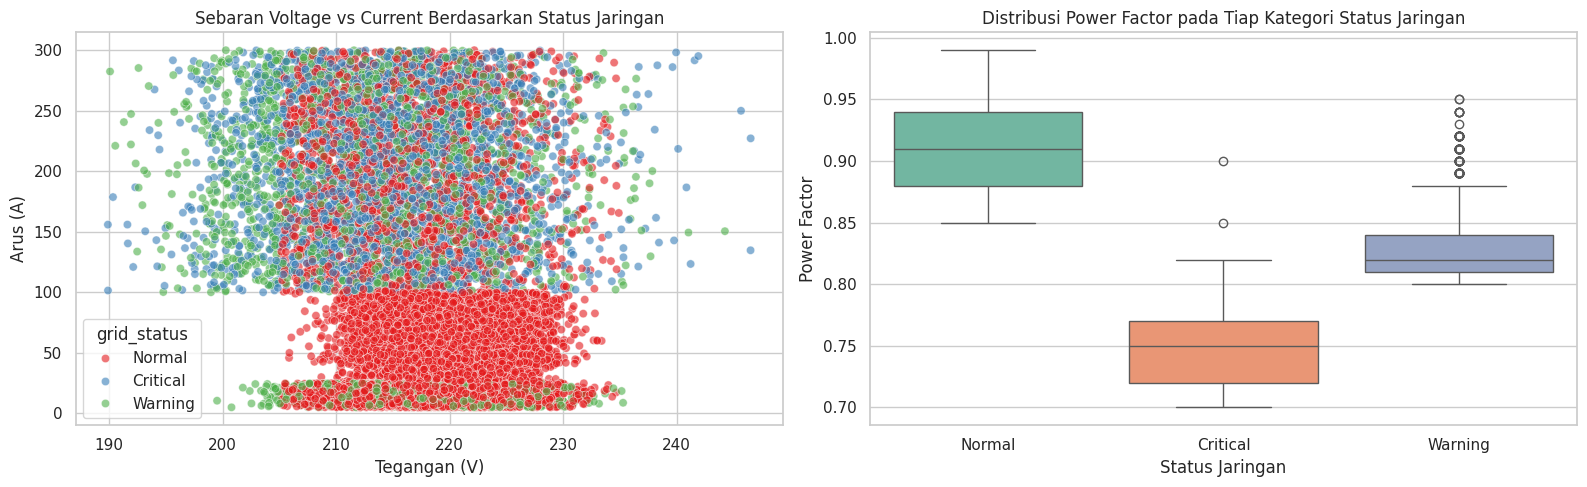

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot hubungan Voltage vs Current dipisahkan warna status jaringan
sns.scatterplot(data=df_grid, x='voltage', y='current', hue='grid_status', palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Sebaran Voltage vs Current Berdasarkan Status Jaringan')
axes[0].set_xlabel('Tegangan (V)')
axes[0].set_ylabel('Arus (A)')

# Boxplot Faktor Daya terhadap Status Jaringan
sns.boxplot(data=df_grid, x='grid_status', y='power_factor', palette='Set2', ax=axes[1])
axes[1].set_title('Distribusi Power Factor pada Tiap Kategori Status Jaringan')
axes[1].set_xlabel('Status Jaringan')
axes[1].set_ylabel('Power Factor')

plt.tight_layout()
plt.show()

=== ANALISIS MENDALAM: PENGARUH ZONA PADA KUALITAS JARINGAN ===


/tmp/ipykernel_171870/3697624760.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_grid, x='zone', y='power_factor', palette='coolwarm', ax=axes[1])


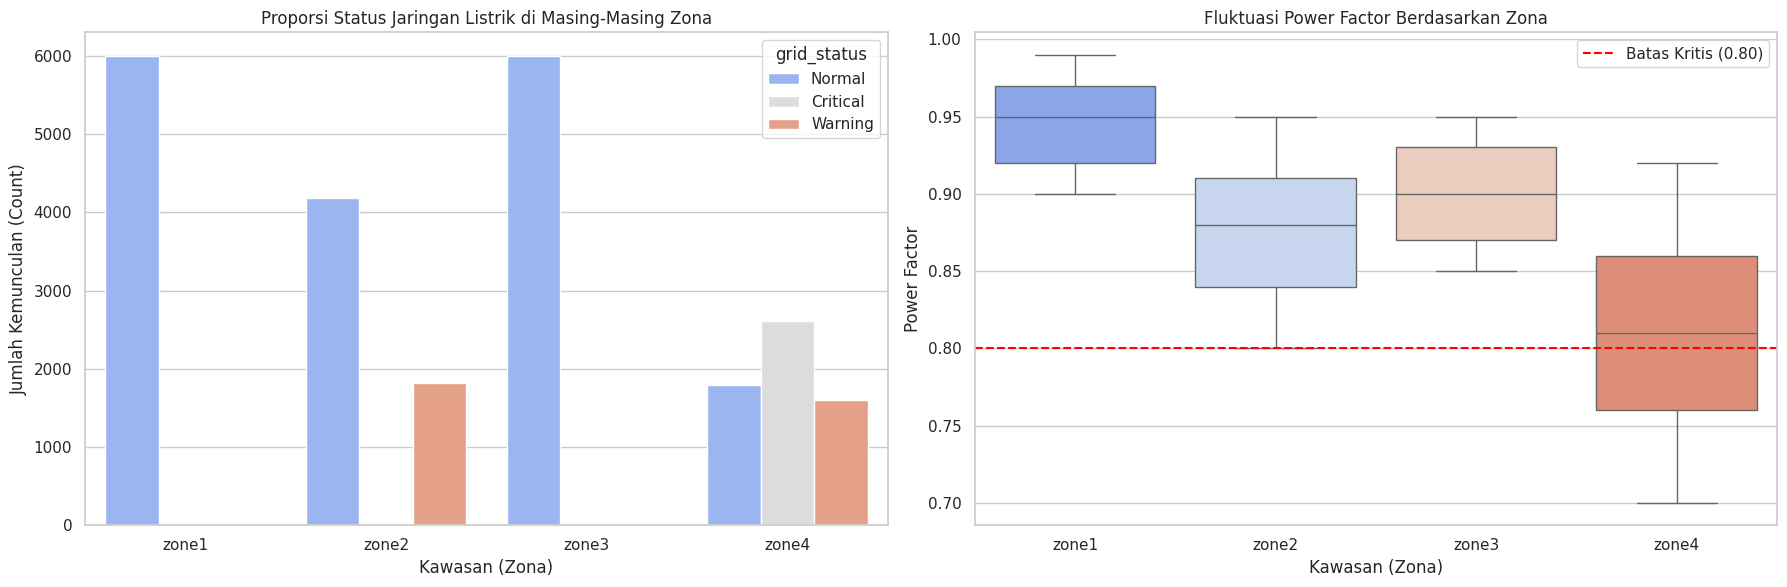

Interpretasi:
- Mesin berat di Zone 4 (Pabrik) sering merusak kualitas Power Factor, sehingga lebih banyak berstatus Warning/Critical.
- Zone 1 (Residensial Atas) memiliki infrastruktur kelistrikan yang lebih stabil (mayoritas Normal).


In [55]:
print("=== ANALISIS MENDALAM: PENGARUH ZONA PADA KUALITAS JARINGAN ===")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Distribusi Status Jaringan (Normal, Warning, Critical) per Zona
sns.countplot(data=df_grid, x='zone', hue='grid_status', palette='coolwarm', ax=axes[0])
axes[0].set_title('Proporsi Status Jaringan Listrik di Masing-Masing Zona')
axes[0].set_xlabel('Kawasan (Zona)')
axes[0].set_ylabel('Jumlah Kemunculan (Count)')

# Grafik 2: Boxplot Power Factor per Zona
sns.boxplot(data=df_grid, x='zone', y='power_factor', palette='coolwarm', ax=axes[1])
axes[1].axhline(0.80, color='red', linestyle='--', label='Batas Kritis (0.80)')
axes[1].set_title('Fluktuasi Power Factor Berdasarkan Zona')
axes[1].set_xlabel('Kawasan (Zona)')
axes[1].set_ylabel('Power Factor')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Mesin berat di Zone 4 (Pabrik) sering merusak kualitas Power Factor, sehingga lebih banyak berstatus Warning/Critical.")
print("- Zone 1 (Residensial Atas) memiliki infrastruktur kelistrikan yang lebih stabil (mayoritas Normal).")

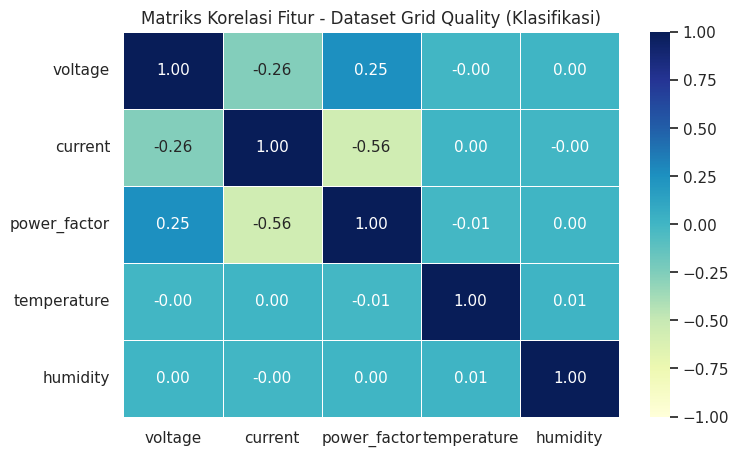

In [56]:
plt.figure(figsize=(8, 5))
numerical_cols_g = df_grid.select_dtypes(include=[np.number]).columns
corr_matrix_g = df_grid[numerical_cols_g].corr()

sns.heatmap(corr_matrix_g, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur - Dataset Grid Quality (Klasifikasi)')
plt.show()

In [57]:
print("=== 3. DATA INTEGRITY CHECK: ENERGY SENSORS ===")
df_sensors = pd.read_csv('../data/energy_sensors.csv')

print(f"Dimensi Dataset: {df_sensors.shape[0]} baris, {df_sensors.shape[1]} kolom")
print(f"Total Missing Values: {df_sensors.isnull().sum().sum()}")
print(f"Total Baris Duplikat: {df_sensors.duplicated().sum()}")

print("\nStatistik Deskriptif Fitur Utama:")
print(df_sensors.describe())

=== 3. DATA INTEGRITY CHECK: ENERGY SENSORS ===
Dimensi Dataset: 24000 baris, 7 kolom
Total Missing Values: 0
Total Baris Duplikat: 0

Statistik Deskriptif Fitur Utama:
       sensor_value  timestamp_hour  rolling_mean_1h       z_score
count  24000.000000    24000.000000     24000.000000  24000.000000
mean     345.078729       11.500000       345.088505      0.532285
std      343.974520        6.922331       344.059532      2.553648
min       48.820000        0.000000        44.310000     -4.370000
25%      123.577500        5.750000       121.345000     -0.640000
50%      203.120000       11.500000       202.320000      0.070000
75%      602.710000       17.250000       602.717500      0.800000
max     1999.940000       23.000000      2002.760000     15.000000


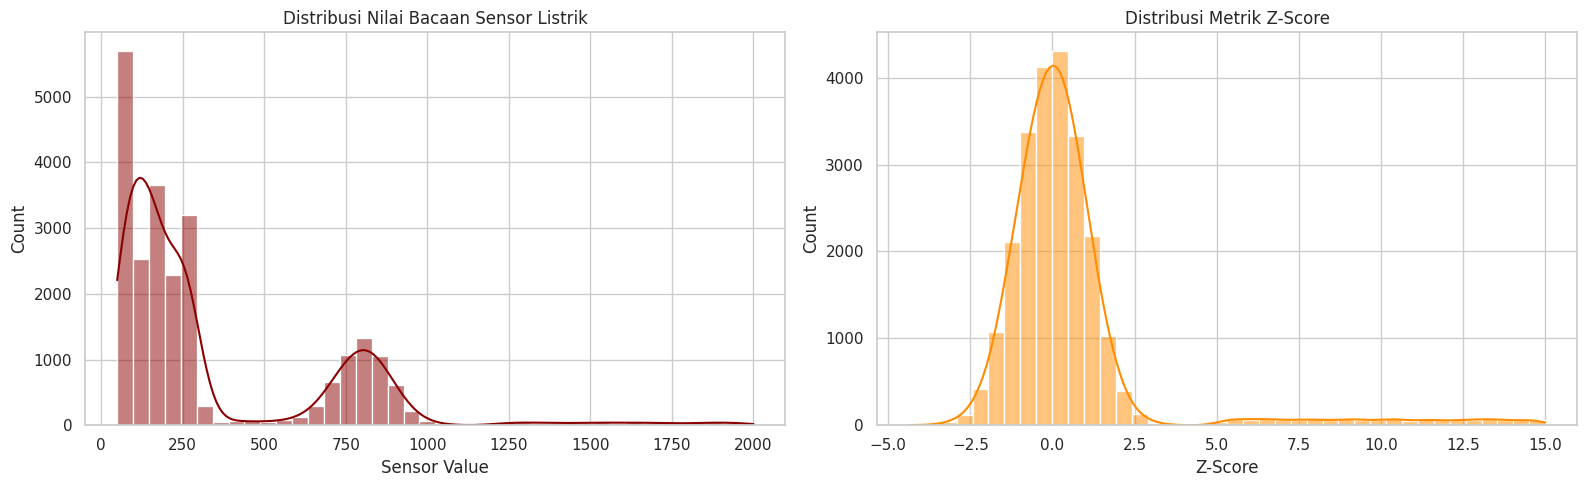

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi Nilai Sensor
sns.histplot(df_sensors['sensor_value'], kde=True, ax=axes[0], color='darkred', bins=40)
axes[0].set_title('Distribusi Nilai Bacaan Sensor Listrik')
axes[0].set_xlabel('Sensor Value')

# Distribusi Z-Score untuk analisis matematis pencilan
sns.histplot(df_sensors['z_score'], kde=True, ax=axes[1], color='darkorange', bins=40)
axes[1].set_title('Distribusi Metrik Z-Score')
axes[1].set_xlabel('Z-Score')

plt.tight_layout()
plt.show()

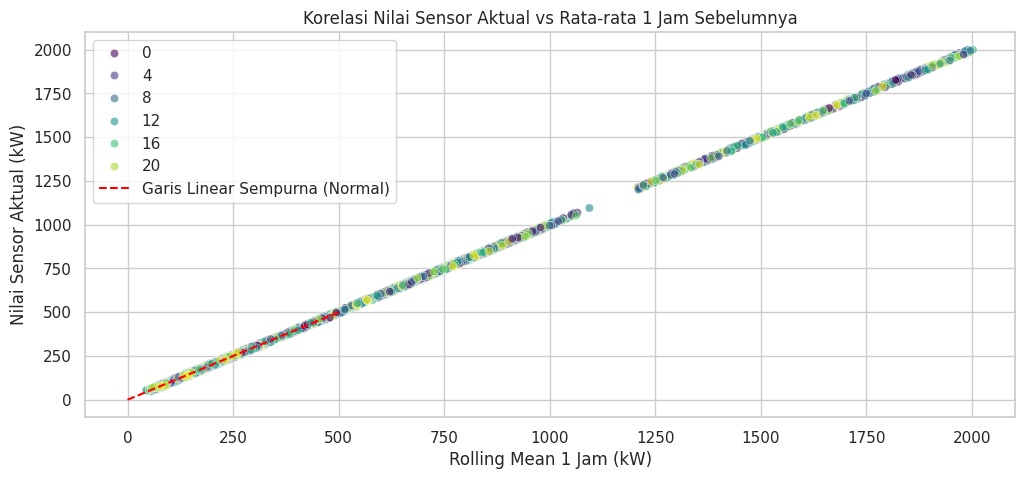

In [59]:
# Menganalisis deviasi nilai sensor saat ini terhadap rata-rata bergulir 1 jam sebelumnya
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_sensors, x='rolling_mean_1h', y='sensor_value', hue='timestamp_hour', palette='viridis', alpha=0.6)
plt.plot([0, 500], [0, 500], color='red', linestyle='--', label='Garis Linear Sempurna (Normal)')
plt.title('Korelasi Nilai Sensor Aktual vs Rata-rata 1 Jam Sebelumnya')
plt.xlabel('Rolling Mean 1 Jam (kW)')
plt.ylabel('Nilai Sensor Aktual (kW)')
plt.legend()
plt.show()

=== ANALISIS MENDALAM: PENYEBARAN ANOMALI SENSOR PER ZONA ===


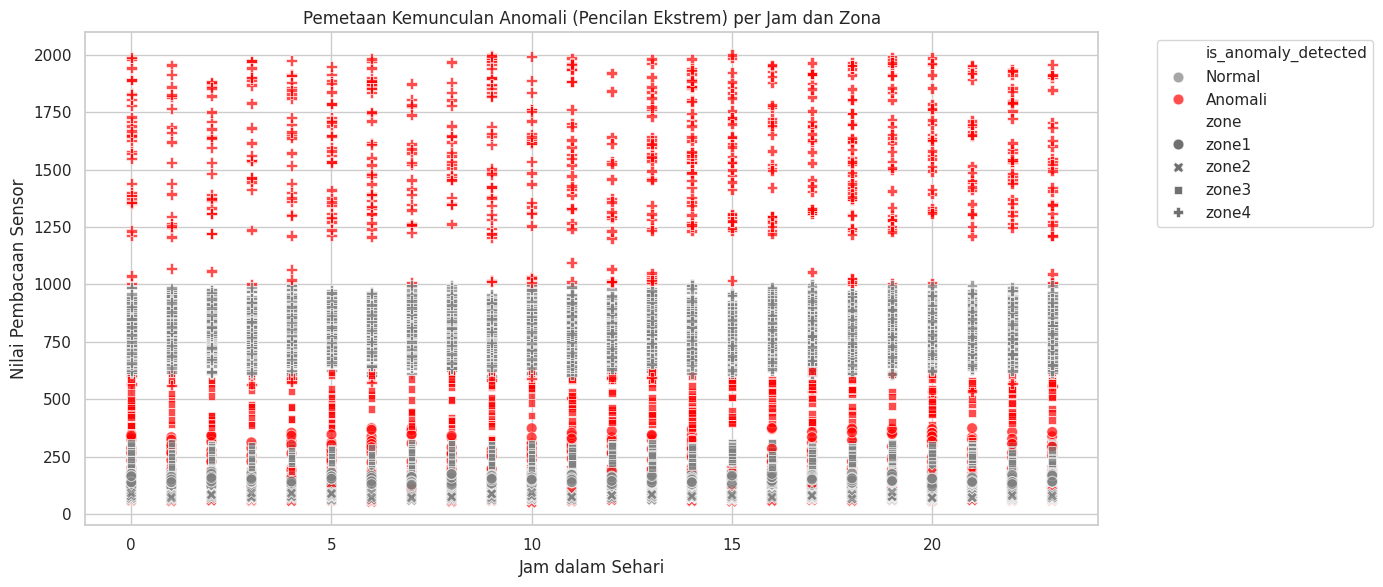

Interpretasi:
- Rentang baseline nilai sensor tiap zona sangat terpisah (Z4~800, Z3~250, Z1~150, Z2~80).
- Titik-titik merah (Anomali) lebih padat terlihat pada baseline Zone 4 dibandingkan zona lainnya.


In [60]:
print("=== ANALISIS MENDALAM: PENYEBARAN ANOMALI SENSOR PER ZONA ===")

plt.figure(figsize=(14, 6))

# Menentukan batas deteksi anomali sederhana berdasarkan Z-Score untuk visualisasi
df_sensors['is_anomaly_detected'] = df_sensors['z_score'].apply(lambda x: 'Anomali' if x > 2.5 or x < -2.5 else 'Normal')

# Scatterplot nilai sensor dipisahkan per zona
sns.scatterplot(data=df_sensors, x='timestamp_hour', y='sensor_value', 
                hue='is_anomaly_detected', style='zone', 
                palette={'Normal': 'gray', 'Anomali': 'red'}, 
                s=60, alpha=0.7)

plt.title('Pemetaan Kemunculan Anomali (Pencilan Ekstrem) per Jam dan Zona')
plt.xlabel('Jam dalam Sehari')
plt.ylabel('Nilai Pembacaan Sensor')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Rentang baseline nilai sensor tiap zona sangat terpisah (Z4~800, Z3~250, Z1~150, Z2~80).")
print("- Titik-titik merah (Anomali) lebih padat terlihat pada baseline Zone 4 dibandingkan zona lainnya.")

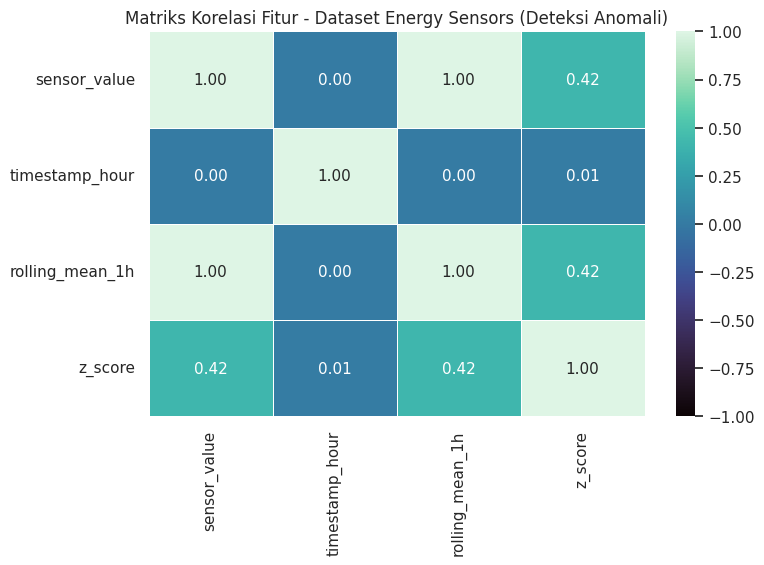

In [61]:
plt.figure(figsize=(8, 5))
numerical_cols_s = df_sensors.select_dtypes(include=[np.number]).columns
corr_matrix_s = df_sensors[numerical_cols_s].corr()

sns.heatmap(corr_matrix_s, annot=True, cmap='mako', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur - Dataset Energy Sensors (Deteksi Anomali)')
plt.show()